In [3]:
import torch
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
# import metaworld
gym.register_envs(gymnasium_robotics)

import cv2
from pathlib import Path
import rospkg

# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{0}" if torch.cuda.is_available() else "cpu")

(400, 400, 3)


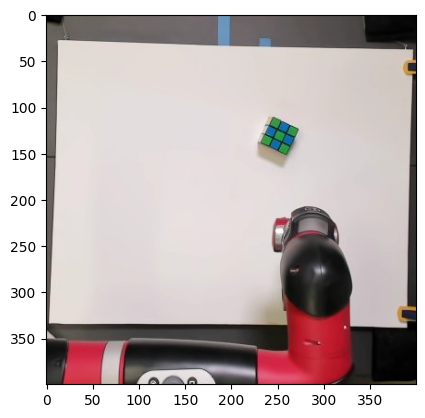

In [4]:
cv2.cvtColor(torch.zeros((400, 400, 3)).to(device).detach().cpu().numpy(), cv2.COLOR_BGR2RGB)

img = cv2.imread("/media/ayush/Extreme Pro/sawyer_images/captured_raw_0000.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img[220:620, 460:860, :]
print(img.shape)
plt.imshow(img)

In [27]:
def visualize_dataset(dataset_path, output_video="hardware_dataset.mp4", fps=10):
    """
    Load hardware dataset and create video visualization
    """
    # Load dataset
    print(f"Loading dataset from {dataset_path}")
    data = torch.load(dataset_path)
    
    prev_images = data["prev_images"]  # (N, past_length, H, W, C)
    next_images = data["next_images"]  # (N, pred_length, H, W, C)
    actions = data["actions"]          # (N, pred_length, 2)
    
    N, past_length, H, W, C = prev_images.shape
    _, pred_length, _, _, _ = next_images.shape
    
    print(f"Dataset: {N} samples, {past_length} past frames, {pred_length} pred frames")
    print(f"Image shape: ({H}, {W}, {C})")
    
    # Setup video writer
    # fourcc = cv2.VideoWriter_fourcc(*'avc1')  # or try 'H264', 'X264'
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_video, fourcc, fps, (W, H))
    
    # Process each sample
    for i in tqdm(range(N)):
        # Visualize past frames
        for t in [past_length-1]: # range(past_length)
            frame = prev_images[i, t].numpy()
            frame = (frame * 255).astype(np.uint8)  # Convert to uint8
            # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # OpenCV uses BGR
            
            # Add text overlay
            # cv2.putText(frame, f"Sample {i+1}/{N} | Past t={t}", 
            #            (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
            out.write(frame)
        
        # Visualize predicted frames
        for t in [0]: # range(pred_length):
            frame = next_images[i, t].numpy()
            frame = (frame * 255).astype(np.uint8)
            # frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Add action info
            # action = actions[i, t].numpy()
            # cv2.putText(frame, f"Sample {i+1}/{N} | Next t={t}", 
            #            (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.1, (0, 255, 255), 1)
            # cv2.putText(frame, f"Action: [{action[0]:.3f}, {action[1]:.3f}]", 
            #            (5, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.2, (0, 255, 255), 1)
            # out.write(frame)
    
    out.release()
    print(f"Video saved to {output_video}")
    print(f"Total frames: {N * (past_length + pred_length)}")

In [28]:
dataset_dir = Path(os.getcwd()).parent.parent / "data" / "hardware"
dataset_path = dataset_dir / "hardware_1k.pt"
output_path = dataset_dir / "hardware_dataset_viz.avi"

visualize_dataset(dataset_path, output_path, fps=10)

/tmp/ipykernel_1320083/109855740.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(dataset_path)
  0%|          | 0/1000 [00:00<?, ?it/s]

Loading dataset from /home/ayush/Desktop/sawyer_moveit_ws/src/E2C/data/hardware/hardware_1k.pt
Dataset: 1000 samples, 3 past frames, 3 pred frames
Image shape: (64, 64, 3)


100%|██████████| 1000/1000 [00:00<00:00, 8203.10it/s]

Video saved to /home/ayush/Desktop/sawyer_moveit_ws/src/E2C/data/hardware/hardware_dataset_viz.avi
Total frames: 6000


In [3]:
import os
os.environ['MUJOCO_GL'] = 'egl'
# disp = Display(visible=0, size=(480, 480))
# disp.start()

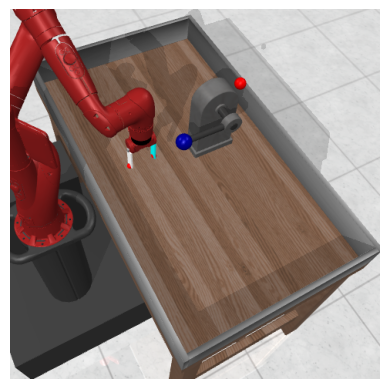

In [6]:
env = gym.make('Meta-World/MT1', env_name='lever-pull-v3', render_mode='rgb_array', camera_name='corner3')
obs, _ = env.reset()
img = env.render()
plt.imshow(np.rot90(img, k=2))
plt.axis('off')
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

(400, 600, 3)
(400, 600, 3)
(400, 600, 3)


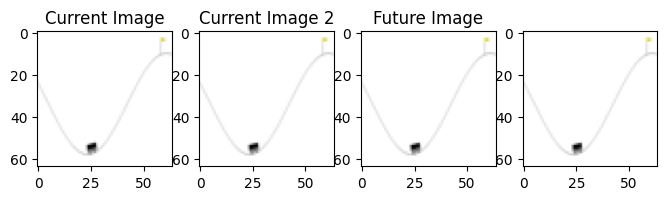

 75%|███████▌  | 3/4 [00:00<00:00, 20.28it/s]

(400, 600, 3)


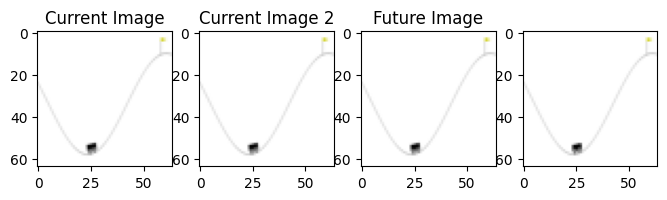

100%|██████████| 4/4 [00:00<00:00, 13.79it/s]

Failures (resets): 0


In [ ]:
env_name = "AntMaze_UMaze-v5" # agent centric view
env_name = "PointMaze_UMaze-v3"
env_name = "MountainCarContinuous-v0"
env = gym.make(env_name, render_mode="rgb_array") #, continuing_task=True)

num_prev = 3
data_length = num_prev + 1
obs, _ = env.reset(seed=rand_seed)

dataset = []  # List of (obs, action, image)
next_imgs = []
obs_arr = []
acts_arr = []

fail_counter = 0
for obs_counter in tqdm(range(data_length)):
    # if obs_counter + 3 >= data_length:
    #     break
    if len(next_imgs) == 0:
        rendered_img = env.render()
        # rendered_img = rendered_img[:, 50:-50, :] # Acrobot
        # rendered_img = rendered_img[100:-50, 100:-100, :]
        # rendered_img = rendered_img[110:-70, 20:-20, :]
        img_resize = Image.fromarray(rendered_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(img_resize))
        obs_arr.append(obs.copy())

    act = env.action_space.sample()
    next_obs, rew, done, _, _ = env.step(act)
    acts_arr.append(act)
    
    if done:
        fail_counter += 1
        obs, _ = env.reset()
        next_imgs = []
        obs_arr = []
        acts_arr = []
    else:
        if len(next_imgs) == num_prev + 1:
            obs_arr.pop(0)
            next_imgs.pop(0)
            acts_arr.pop(0)
        next_img = env.render()
        # next_img = next_img[:, 50:-50, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, 100:-100, :] # [y dir, x dir, color]
        # next_img = next_img[100:-50, :-100, :]
        # next_img = next_img[110:-70, 20:-20, :]
        next_img = Image.fromarray(next_img).resize((64, 64)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        # next_img = Image.fromarray(next_img).resize((96, 96)) #.resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8)).resize((cropped.shape[1] // 8 * 8, cropped.shape[0] // 8 * 8))
        next_imgs.append(np.asarray(next_img))
        obs_arr.append(next_obs.copy())
        
        if len(next_imgs) == num_prev + 1:
            
            fig, ax = plt.subplots(1, num_prev+1, figsize=(8, 10))
            ax[0].set_title("Current Image")
            ax[1].set_title("Current Image 2")
            ax[2].set_title("Future Image")
            for i, img in enumerate(next_imgs):
                ax[i].imshow(img)
                # ax[i].set_xlabel(np.array2string(obs_arr[i], formatter={'float_kind': lambda x: "%.2f" % x}))
            plt.show()
            plt.close(fig)
            # Store only valid transitions
            dataset.append({
                'obs': np.asarray(obs_arr).copy(),
                'action': np.asarray(acts_arr).copy(),
                'image': np.asarray(next_imgs[:-1]).copy(),
                'next_image': next_imgs[-1].copy()
            })
        obs = next_obs
print(f"Failures (resets): {fail_counter}")